# GMM and Flow Matching: Pedagogical Example

This notebook illustrates how GMM and Flow Matching handle:
- Noisy data with missing regions
- Multi-modal conditional distributions
- Inverse problems

**Problem:** y = |x| with missing data from -0.5 to 0.5

**Authors:** Victor Alves and John R. Kitchin

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.11 (main, Jun 12 2025, 12:22:42) [Clang 20.1.4 ]
Platform: macOS-15.6.1-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.4.0
scipy                1.16.3
matplotlib           3.10.7


sklearn              1.6.1


torch                2.7.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2026-01-11 14:36:55
Initial memory usage: 329.52 MB


## System Information

This section documents the computational environment used to run this notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import warnings
import os

# Force CPU for JAX
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch

# Import reusable utilities
from generative_optimization import (
    best_gmm,
    ConditionalFlowMatching
)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.size'] = 10

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

print("Setup complete")

Setup complete


## Generate Data: y = |x| with Gap

We create data from y = |x| + noise, but exclude the region -0.5 ≤ x ≤ 0.5 to simulate missing data.

In [3]:
# Generate data: y = |x| with noise, excluding middle region
n_samples = 300

# Left arm: x in [-1, -0.5]
x_left = np.random.uniform(-1, -0.5, n_samples // 2)
y_left = np.abs(x_left) + np.random.normal(0, 0.05, n_samples // 2)

# Right arm: x in [0.5, 1]
x_right = np.random.uniform(0.5, 1, n_samples // 2)
y_right = np.abs(x_right) + np.random.normal(0, 0.05, n_samples // 2)

# Combine
x_data = np.concatenate([x_left, x_right])
y_data = np.concatenate([y_left, y_right])

# Stack into data array
data = np.column_stack([x_data, y_data])

print(f"Generated {len(data)} samples")
print(f"x range: [{x_data.min():.2f}, {x_data.max():.2f}]")
print(f"y range: [{y_data.min():.2f}, {y_data.max():.2f}]")
print(f"Gap: -0.5 to 0.5 (no data)")

Generated 300 samples
x range: [-1.00, 1.00]
y range: [0.44, 1.08]
Gap: -0.5 to 0.5 (no data)


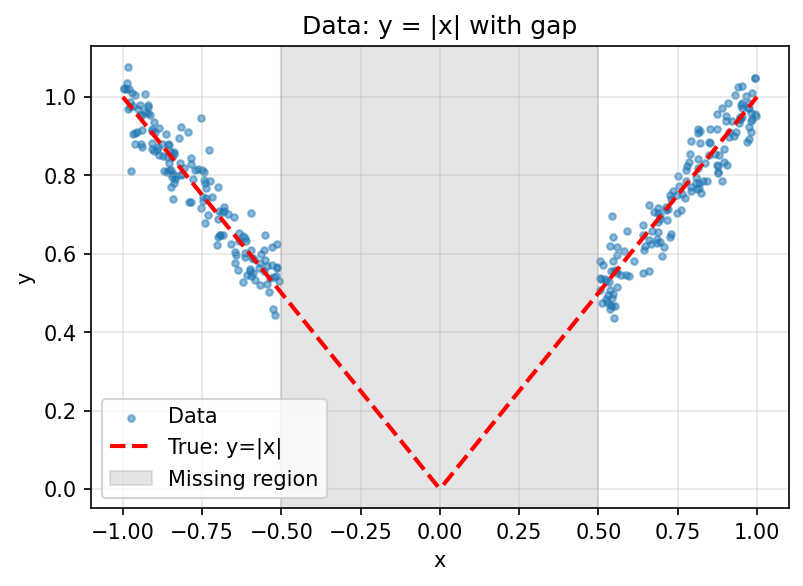

In [4]:
# Quick visualization of the data
plt.figure(figsize=(6, 4))
plt.scatter(x_data, y_data, s=10, alpha=0.5, label='Data')
x_true = np.linspace(-1, 1, 200)
y_true = np.abs(x_true)
plt.plot(x_true, y_true, 'r--', lw=2, label='True: y=|x|')
plt.axvspan(-0.5, 0.5, alpha=0.2, color='gray', label='Missing region')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data: y = |x| with gap')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## GMM: Fit with Two Gaussians

We fit a GMM with 2 components to capture the two "arms" of the V-shape.

In [5]:
# Fit GMM with 2 components (we know this is optimal for this problem)
from gmr import GMM

gmm = GMM(n_components=2, random_state=42)
gmm.from_samples(data)

print(f"GMM trained with {gmm.n_components} components")
print(f"\nComponent means:")
for i in range(gmm.n_components):
    print(f"  Component {i}: x={gmm.means[i, 0]:.3f}, y={gmm.means[i, 1]:.3f}")
print(f"\nComponent priors: {gmm.priors}")

GMM trained with 2 components

Component means:
  Component 0: x=-0.764, y=0.766
  Component 1: x=0.758, y=0.753

Component priors: [0.50000001 0.49999999]


## Visualization with Marginals and Conditional

Create a comprehensive figure showing:
- Central panel: data + GMM fit
- Side panels: marginal distributions P(x) and P(y)
- Horizontal line at y=0.75 with conditional P(x|y=0.75)

Saved: fig_gmm_example.png


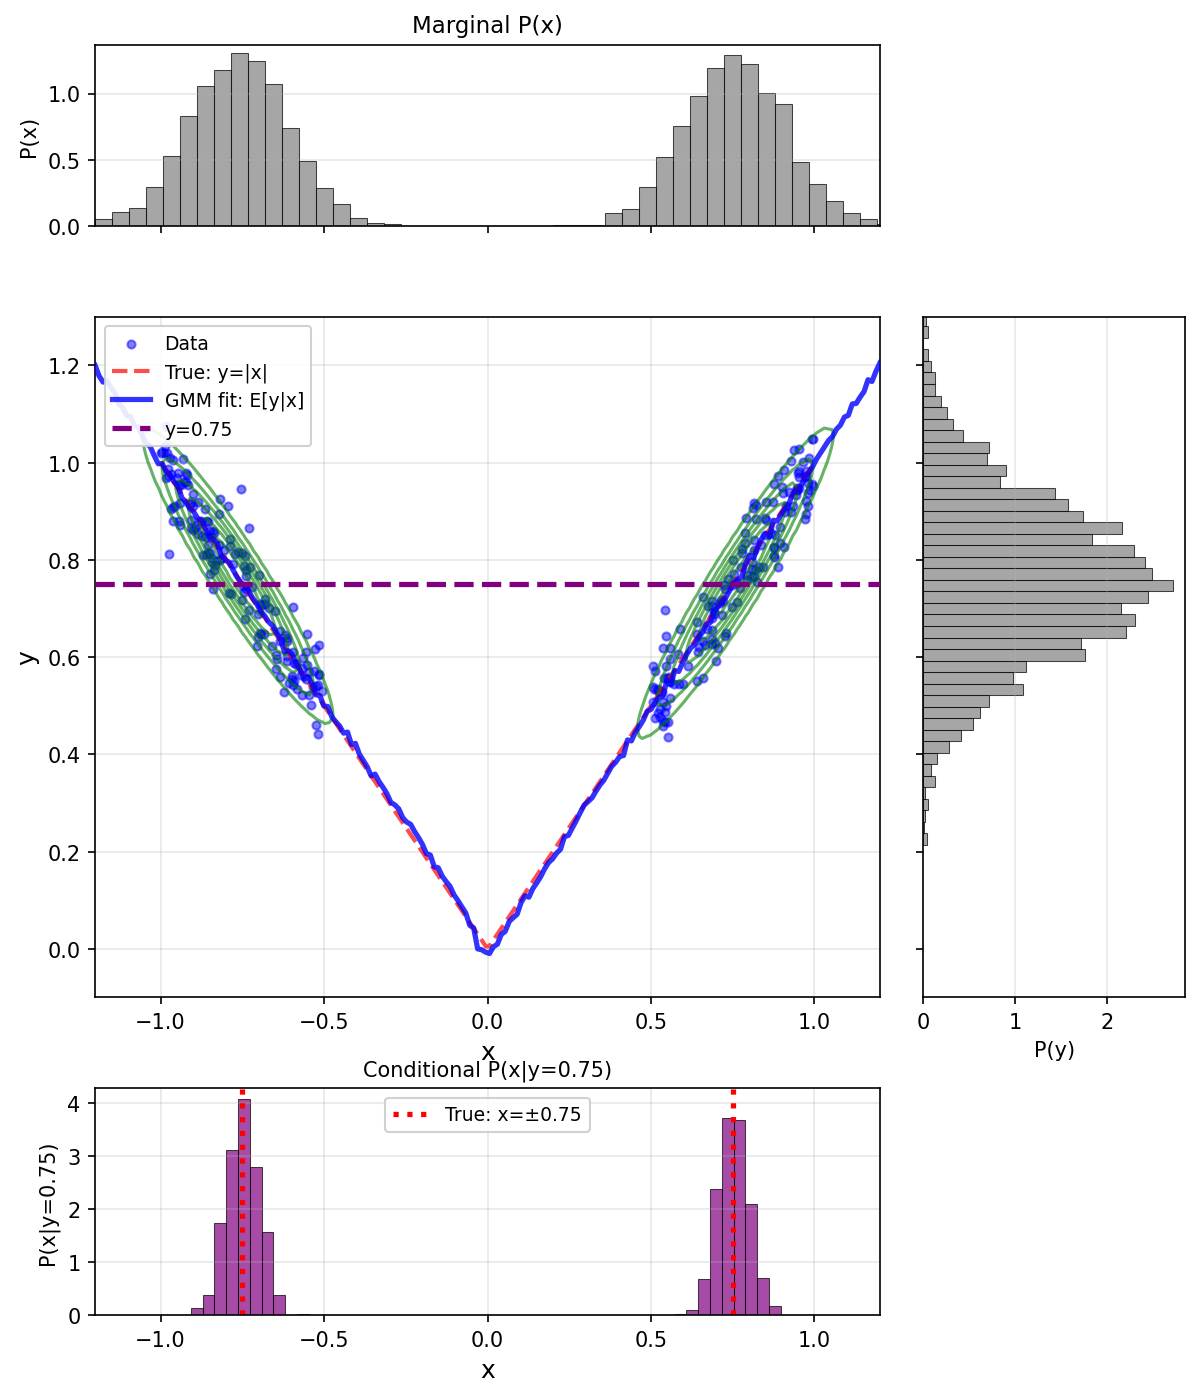


Conditional P(x | y=0.75) statistics:
  Mean: -0.015
  Std: 0.752
  True values: x = ±0.75

Mode distribution:
  Left mode (x<0): 1023 samples, mean = -0.748
  Right mode (x>0): 977 samples, mean = 0.752


In [6]:
# Helper function to work around gmr.GMM.condition bug in v2.0.2
from gmr import MVN

def sample_gmm_conditional(gmm, cond_indices, cond_values, n_samples=1000):
    """Sample from P(x|y) by conditioning each GMM component and mixing.
    
    Workaround for gmr.GMM.condition() bug in version 2.0.2.
    """
    cond_values = np.atleast_1d(cond_values)
    n_components = gmm.n_components
    
    # For each component, compute the conditional distribution and weight
    conditional_means = []
    conditional_covs = []
    weights = []
    
    for k in range(n_components):
        mvn = MVN(mean=gmm.means[k], covariance=gmm.covariances[k])
        
        # Condition this component on the target value
        cond_mvn = mvn.condition(cond_indices, cond_values)
        conditional_means.append(cond_mvn.mean)
        conditional_covs.append(cond_mvn.covariance)
        
        # Weight by prior * P(cond_value | component k)
        marginal = mvn.marginalize(cond_indices)
        likelihood = marginal.to_probability_density(cond_values.reshape(1, -1))[0]
        weights.append(gmm.priors[k] * likelihood)
    
    # Normalize weights
    weights = np.array(weights)
    weights = weights / weights.sum()
    
    # Sample from mixture
    samples = []
    component_counts = np.random.multinomial(n_samples, weights)
    
    for k in range(n_components):
        if component_counts[k] > 0:
            mean = conditional_means[k]
            cov = conditional_covs[k]
            if np.isscalar(cov):
                cov = np.array([[cov]])
            comp_samples = np.random.multivariate_normal(mean.flatten(), cov, component_counts[k])
            samples.append(comp_samples)
    
    return np.vstack(samples)

# Create figure with GridSpec for custom layout
fig = plt.figure(figsize=(12, 11))
gs = GridSpec(3, 3, figure=fig, width_ratios=[1, 3, 1], height_ratios=[0.8, 3, 1],
              hspace=0.25, wspace=0.1)

# Main central panel: scatter plot with GMM contours
ax_main = fig.add_subplot(gs[1, 1])

# Top panel: P(x) marginal
ax_top = fig.add_subplot(gs[0, 1], sharex=ax_main)

# Right panel: P(y) marginal  
ax_right = fig.add_subplot(gs[1, 2], sharey=ax_main)

# Bottom panel: conditional P(x|y=0.75)
ax_bottom = fig.add_subplot(gs[2, 1], sharex=ax_main)

# ============ Main panel: Data + GMM fit ============
# Scatter data
ax_main.scatter(x_data, y_data, s=15, alpha=0.5, c='blue', label='Data')

# Plot true function
x_plot = np.linspace(-1, 1, 200)
y_plot = np.abs(x_plot)
ax_main.plot(x_plot, y_plot, 'r--', lw=2, alpha=0.7, label='True: y=|x|')

# Compute GMM fit: E[y|x] for all x values
x_fit = np.linspace(-1.2, 1.2, 200)
y_fit = []
for x_val in x_fit:
    # Condition GMM on x and get expected y using workaround
    try:
        y_samples = sample_gmm_conditional(gmm, [0], x_val, n_samples=100)
        y_expected = y_samples.mean()
        y_fit.append(y_expected)
    except:
        y_fit.append(np.nan)

# Plot GMM fit as solid blue line
ax_main.plot(x_fit, y_fit, 'b-', lw=2.5, alpha=0.8, label='GMM fit: E[y|x]', zorder=4)

# GMM contours
x_grid = np.linspace(-1.2, 1.2, 100)
y_grid = np.linspace(-0.1, 1.3, 100)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

# Compute GMM density using gmr's internal representation
from scipy.stats import multivariate_normal

densities = np.zeros(len(grid_points))
for k in range(gmm.n_components):
    mvn_scipy = multivariate_normal(mean=gmm.means[k], cov=gmm.covariances[k])
    densities += gmm.priors[k] * mvn_scipy.pdf(grid_points)
densities = densities.reshape(X_grid.shape)

# Plot contours
contours = ax_main.contour(X_grid, Y_grid, densities, levels=6, 
                            colors='green', alpha=0.6, linewidths=1.5)

# Horizontal line at y=0.75
y_target = 0.75
ax_main.axhline(y_target, color='purple', ls='--', lw=2.5, 
                label=f'y={y_target}', zorder=5)

ax_main.set_xlabel('x', fontsize=12)
ax_main.set_ylabel('y', fontsize=12)
ax_main.set_xlim(-1.2, 1.2)
ax_main.set_ylim(-0.1, 1.3)
ax_main.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax_main.grid(True, alpha=0.3)

# ============ Top panel: P(x) marginal ============
# Sample from GMM to get marginal
samples_marginal = gmm.sample(5000)
ax_top.hist(samples_marginal[:, 0], bins=50, density=True, 
            alpha=0.7, color='gray', edgecolor='black', linewidth=0.5)
ax_top.set_ylabel('P(x)', fontsize=10)
ax_top.set_title('Marginal P(x)', fontsize=11)
ax_top.tick_params(labelbottom=False)
ax_top.grid(True, alpha=0.3, axis='y')
ax_top.set_xlim(-1.2, 1.2)

# ============ Right panel: P(y) marginal ============
ax_right.hist(samples_marginal[:, 1], bins=50, density=True, 
              alpha=0.7, color='gray', edgecolor='black', 
              orientation='horizontal', linewidth=0.5)
ax_right.set_xlabel('P(y)', fontsize=10)
ax_right.tick_params(labelleft=False)
ax_right.grid(True, alpha=0.3, axis='x')

# ============ Bottom panel: Conditional P(x|y=0.75) ============
# Condition GMM on y=0.75 and sample x values using workaround
x_samples = sample_gmm_conditional(gmm, [1], y_target, n_samples=2000)

# Plot conditional distribution
ax_bottom.hist(x_samples[:, 0], bins=50, density=True, 
               alpha=0.7, color='purple', edgecolor='black', linewidth=0.5)
ax_bottom.axvline(-y_target, color='red', ls=':', lw=2.5, 
                  label=f'True: x=±{y_target}')
ax_bottom.axvline(y_target, color='red', ls=':', lw=2.5)
ax_bottom.set_xlabel('x', fontsize=12)
ax_bottom.set_ylabel(f'P(x|y={y_target})', fontsize=10)
ax_bottom.set_title(f'Conditional P(x|y={y_target})', fontsize=10)
ax_bottom.legend(fontsize=9, loc='upper center', framealpha=0.9)
ax_bottom.grid(True, alpha=0.3)
ax_bottom.set_xlim(-1.2, 1.2)

# Save figure
plt.savefig('fig_gmm_example.png', dpi=300, bbox_inches='tight')
print("Saved: fig_gmm_example.png")

plt.show()

# Print statistics
print(f"\nConditional P(x | y={y_target}) statistics:")
print(f"  Mean: {x_samples[:, 0].mean():.3f}")
print(f"  Std: {x_samples[:, 0].std():.3f}")
print(f"  True values: x = ±{y_target}")

# Count samples in each mode
left_mode = x_samples[:, 0] < 0
right_mode = x_samples[:, 0] > 0
print(f"\nMode distribution:")
print(f"  Left mode (x<0): {left_mode.sum()} samples, mean = {x_samples[left_mode, 0].mean():.3f}")
print(f"  Right mode (x>0): {right_mode.sum()} samples, mean = {x_samples[right_mode, 0].mean():.3f}")

**Figure 1**: GMM fit for $y = |x|$ with missing data in the region $-0.5 \leq x \leq 0.5$. The central panel shows the data (blue points), true function (red dashed), GMM fit $E[y|x]$ (blue solid line), and GMM density contours (green). The marginal distributions $P(x)$ (top) and $P(y)$ (right) show the overall data distribution. The bottom panel shows the conditional distribution $P(x|y=0.75)$, which is bimodal with modes at $x \approx \pm 0.75$, demonstrating GMM's ability to capture multi-modal inverse solutions despite missing data.

## Key Observations

1. **Two Gaussians capture the structure**: Each component models one "arm" of the V-shape

2. **Missing data handled gracefully**: GMM interpolates through the gap (-0.5 to 0.5)

3. **Bimodal conditional distribution**: When we ask "what x gives y=0.75?", the GMM correctly returns both x≈-0.75 and x≈0.75

4. **Marginals show the overall distribution**: P(x) is bimodal, P(y) is concentrated where we have data

This demonstrates GMM's ability to:
- Learn complex distributions from data
- Handle missing data regions  
- Perform inverse inference (y → x)
- Capture multi-modal solutions

---
## Flow Matching: Same Problem

Now let's solve the same problem with Flow Matching to compare approaches.

**Key difference**: Flow Matching learns a transformation from a simple distribution to data, conditioned on target values.

## Flow Matching: Train on Same Data

For Flow Matching, we:
1. Train a model to generate x conditioned on y
2. Condition on y=0.75 to sample possible x values
3. Compare with GMM results

In [7]:
# Prepare data: x is what we want to generate, y is the condition
x_train = x_data.reshape(-1, 1)  # Shape: (n_samples, 1)
c_train = y_data.reshape(-1, 1)  # Shape: (n_samples, 1)

print(f"Training data shapes: x={x_train.shape}, c={c_train.shape}")
print(f"We will learn to generate x conditioned on y")

# Train Flow Matching model
fm = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=64, n_layers=3)
fm.fit(x_train, c_train, epochs=500, batch_size=64, verbose=False)

print(f"\nTraining complete")

Training data shapes: x=(300, 1), c=(300, 1)
We will learn to generate x conditioned on y



Training complete


In [8]:
# Sample x values conditioned on y=0.75
x_fm_samples = fm.sample(c_values=[[y_target]], n_samples=2000, n_steps=100)

print(f"Conditional P(x | y={y_target}) from Flow Matching:")
print(f"  Mean: {x_fm_samples.mean():.3f}")
print(f"  Std: {x_fm_samples.std():.3f}")
print(f"  True values: x = ±{y_target}")

# Count samples in each mode
left_mode_fm = x_fm_samples[:, 0] < 0
right_mode_fm = x_fm_samples[:, 0] > 0
print(f"\nMode distribution:")
print(f"  Left mode (x<0): {left_mode_fm.sum()} samples, mean = {x_fm_samples[left_mode_fm, 0].mean():.3f}")
print(f"  Right mode (x>0): {right_mode_fm.sum()} samples, mean = {x_fm_samples[right_mode_fm, 0].mean():.3f}")

Conditional P(x | y=0.75) from Flow Matching:
  Mean: -0.133
  Std: 0.745
  True values: x = ±0.75

Mode distribution:
  Left mode (x<0): 1179 samples, mean = -0.751
  Right mode (x>0): 821 samples, mean = 0.755


Saved: fig_fm_example.png


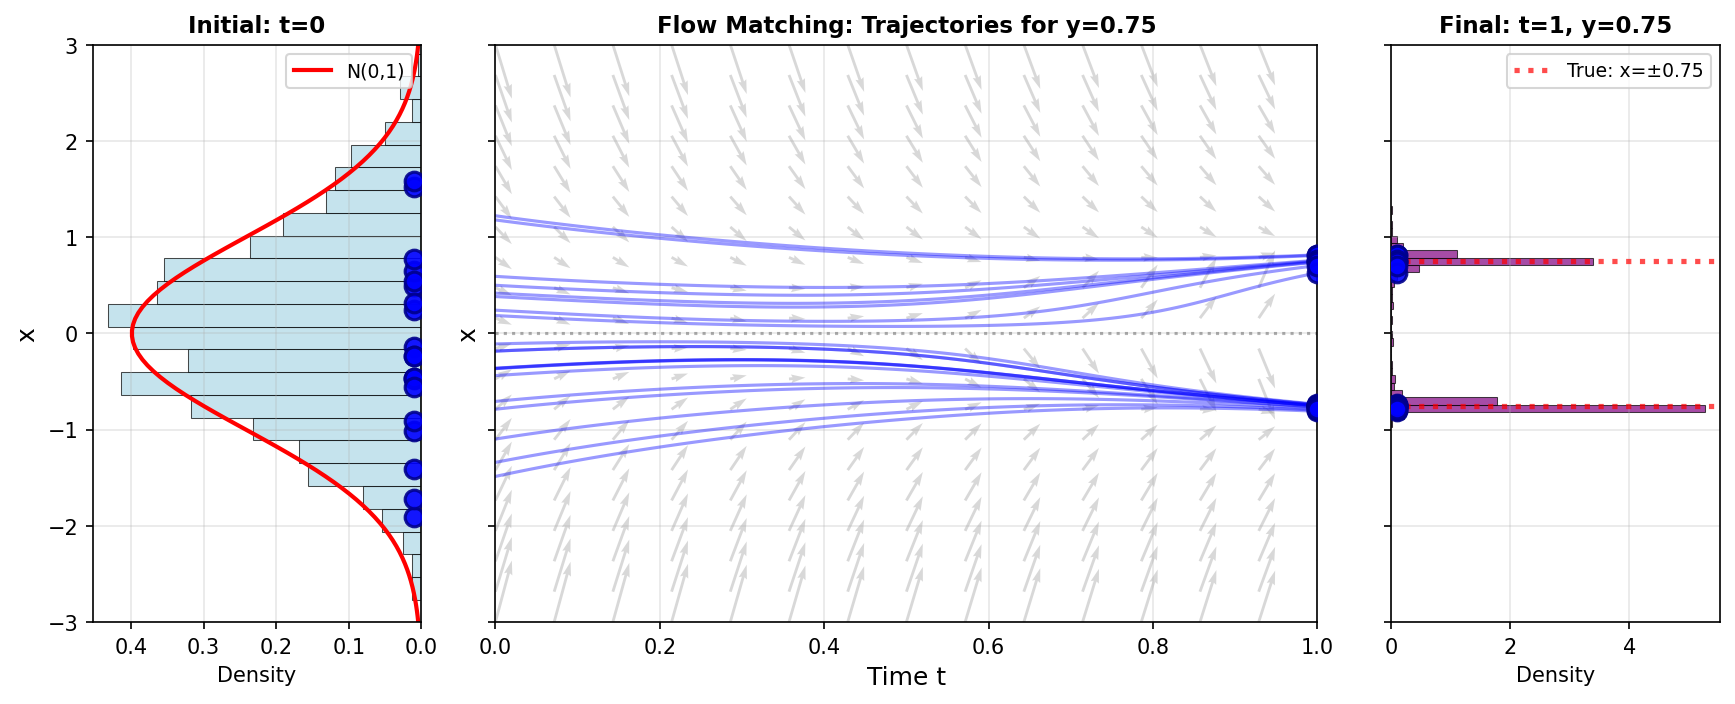


Flow Matching Visualization:
  Generated 1000 trajectories, showing 20 as blue lines
  Left mode: 580 samples, mean = -0.745
  Right mode: 420 samples, mean = 0.761
  True values: x = ±0.75


In [9]:
# Create Flow Matching visualization with initial and final distributions
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 2.5, 1], wspace=0.15)

# ============ Left panel: Initial distribution (Normal) ============
ax_left = fig.add_subplot(gs[0, 0])

# Generate MORE trajectories to get a good histogram, but only show a subset
n_traj_total = 1000  # Total trajectories for histogram
n_traj_show = 20     # Number to visualize
n_time_steps = 100

# Sample initial noise for ALL trajectories
np.random.seed(42)
x0_all = np.random.randn(n_traj_total, 1)

# Plot initial distribution as histogram
ax_left.hist(x0_all[:, 0], bins=30, density=True, alpha=0.7, 
             color='lightblue', edgecolor='black', linewidth=0.5,
             orientation='horizontal')

# Overlay the theoretical N(0,1) distribution
x_range = np.linspace(-3, 3, 100)
from scipy.stats import norm
ax_left.plot(norm.pdf(x_range), x_range, 'r-', lw=2, label='N(0,1)')

# Add blue dots for the trajectories we'll visualize
ax_left.scatter([0.01]*n_traj_show, x0_all[:n_traj_show, 0], s=80, c='blue', alpha=0.9, 
               zorder=5, marker='o', edgecolors='darkblue', linewidths=1.5)

ax_left.set_ylabel('x', fontsize=12)
ax_left.set_xlabel('Density', fontsize=10)
ax_left.set_title('Initial: t=0', fontsize=11, fontweight='bold')
ax_left.set_ylim(-3, 3)
ax_left.grid(True, alpha=0.3)
ax_left.legend(fontsize=9, loc='upper right')
# Flip x-axis so peak points left (toward center)
ax_left.invert_xaxis()

# ============ Center panel: Trajectories and flow field ============
ax_center = fig.add_subplot(gs[0, 1], sharey=ax_left)

# Normalize the conditioning value (same as fm.sample() does)
c_normalized = (torch.tensor([[y_target]], dtype=torch.float32) - fm.c_mean) / (fm.c_std + 1e-8)

# Compute ALL trajectories but only plot a subset
all_final_points = []
trajectories_to_show = []

# Integration parameters matching fm.sample()
n_steps = n_time_steps
dt = 1.0 / n_steps

for i in range(n_traj_total):
    x_t = torch.tensor(x0_all[i:i+1], dtype=torch.float32)
    
    # Store trajectory in UNNORMALIZED space for visualization
    x_unnorm = x_t * (fm.x_std + 1e-8) + fm.x_mean
    traj = [x_unnorm.numpy()[0, 0]]
    
    for step in range(n_steps):
        t_val = torch.tensor(step / n_steps, dtype=torch.float32)
        with torch.no_grad():
            v = fm.model(x_t, t_val, c_normalized)
        x_t = x_t + v * dt
        
        if i < n_traj_show:
            # Unnormalize for trajectory visualization
            x_unnorm = x_t * (fm.x_std + 1e-8) + fm.x_mean
            traj.append(x_unnorm.numpy()[0, 0])
    
    # Unnormalize final point
    x_final = x_t * (fm.x_std + 1e-8) + fm.x_mean
    all_final_points.append(x_final.numpy()[0, 0])
    if i < n_traj_show:
        trajectories_to_show.append(traj)

# Time points for plotting (n_steps + 1 points from 0 to 1)
time_points_plot = np.linspace(0, 1, n_steps + 1)

# Plot only the first n_traj_show trajectories
for traj in trajectories_to_show:
    ax_center.plot(time_points_plot, traj, 'b-', alpha=0.4, lw=1.5)

# Highlight final points of the shown trajectories at t=1
ax_center.scatter([1.0]*n_traj_show, all_final_points[:n_traj_show], 
                  s=80, c='blue', alpha=0.9, zorder=5, marker='o',
                  edgecolors='darkblue', linewidths=1.5)

# Add flow field as quiver plot (in unnormalized space for visualization)
t_grid = np.linspace(0, 1, 15)
x_grid = np.linspace(-3, 3, 20)
T_grid, X_grid = np.meshgrid(t_grid, x_grid)

# Compute velocity at each grid point
U = np.zeros_like(T_grid)
V = np.zeros_like(X_grid)

for i in range(len(x_grid)):
    for j in range(len(t_grid)):
        # Normalize x for model input
        x_val_unnorm = X_grid[i, j]
        x_val_norm = (x_val_unnorm - fm.x_mean.numpy()) / (fm.x_std.numpy() + 1e-8)
        x_val = torch.tensor([[x_val_norm[0]]], dtype=torch.float32)
        t_val = torch.tensor(T_grid[i, j], dtype=torch.float32)
        with torch.no_grad():
            v = fm.model(x_val, t_val, c_normalized)
        # Scale velocity to unnormalized space
        v_unnorm = v.numpy()[0, 0] * (fm.x_std.numpy()[0] + 1e-8)
        V[i, j] = v_unnorm
        U[i, j] = 1.0

# Plot vector field
ax_center.quiver(T_grid, X_grid, U, V, alpha=0.3, color='gray', scale=50)

ax_center.set_xlabel('Time t', fontsize=12)
ax_center.set_ylabel('x', fontsize=12)
ax_center.set_title(f'Flow Matching: Trajectories for y={y_target}', fontsize=11, fontweight='bold')
ax_center.axhline(0, color='k', ls=':', alpha=0.3)
ax_center.grid(True, alpha=0.3)
ax_center.set_xlim(0, 1)
ax_center.set_ylim(-3, 3)
ax_center.tick_params(labelleft=False)

# ============ Right panel: Final conditional distribution ============
ax_right = fig.add_subplot(gs[0, 2], sharey=ax_left)

# Plot histogram from ALL trajectory endpoints
ax_right.hist(all_final_points, bins=30, density=True, 
             alpha=0.7, color='purple', edgecolor='black', linewidth=0.5,
             orientation='horizontal')

# Overlay the trajectory endpoints we visualized as scatter points
ax_right.scatter([0.1]*n_traj_show, all_final_points[:n_traj_show], 
                s=80, c='blue', alpha=0.9, zorder=5, marker='o',
                edgecolors='darkblue', linewidths=1.5)

ax_right.axhline(-y_target, color='red', ls=':', lw=2.5, alpha=0.7)
ax_right.axhline(y_target, color='red', ls=':', lw=2.5, alpha=0.7,
                 label=f'True: x=±{y_target}')
ax_right.set_xlabel('Density', fontsize=10)
ax_right.set_title(f'Final: t=1, y={y_target}', fontsize=11, fontweight='bold')
ax_right.legend(fontsize=9, loc='upper right')
ax_right.grid(True, alpha=0.3)
ax_right.set_ylim(-3, 3)
ax_right.tick_params(labelleft=False)

# Save figure
plt.savefig('fig_fm_example.png', dpi=300, bbox_inches='tight')
print("Saved: fig_fm_example.png")

plt.show()

# Print statistics
all_final_points_arr = np.array(all_final_points)
left_mode_traj = all_final_points_arr < 0
right_mode_traj = all_final_points_arr > 0
print(f"\nFlow Matching Visualization:")
print(f"  Generated {n_traj_total} trajectories, showing {n_traj_show} as blue lines")
print(f"  Left mode: {left_mode_traj.sum()} samples, mean = {all_final_points_arr[left_mode_traj].mean():.3f}")
print(f"  Right mode: {right_mode_traj.sum()} samples, mean = {all_final_points_arr[right_mode_traj].mean():.3f}")
print(f"  True values: x = ±{y_target}")

**Figure 2**: Flow Matching trajectories for $y = |x|$ with missing data. Left panel shows the initial noise distribution $N(0,1)$ at $t=0$. Center panel shows 20 trajectories evolving from noise to data, conditioned on $y=0.75$, with gray arrows indicating the learned velocity field $v(x,t,y=0.75)$. Right panel shows the final conditional distribution $P(x|y=0.75)$ at $t=1$, which is bimodal with modes at $x \approx \pm 0.75$, matching the true inverse solutions. Flow Matching learns to transform a simple Gaussian into a complex bimodal distribution conditioned on the target value.

## Comparison: GMM vs Flow Matching

Both methods successfully:
- Learn the bimodal structure of the data
- Handle the missing data region (-0.5 to 0.5)
- Generate both solutions when conditioned on y=0.75

**Key differences:**

1. **GMM**: 
   - Learns joint distribution P(x, y) explicitly
   - Uses Gaussian components to model density
   - Conditioning is exact through Gaussian conditioning formulas
   - Requires choosing number of components

2. **Flow Matching**:
   - Learns conditional distribution P(x|y) directly
   - Uses neural network to model transformation from noise
   - More flexible for complex, high-dimensional distributions
   - Requires training with epochs and batches

In [10]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2026-01-11 14:36:55
End time:        2026-01-11 14:37:02
Elapsed time:    7.10 seconds (0.12 minutes)
----------------------------------------------------------------------
Initial memory:  329.52 MB
Final memory:    597.25 MB
Memory change:   +267.73 MB


In [11]:
# Direct comparison of conditional distributions
print(f"Conditional P(x | y={y_target}) Comparison:")
print("=" * 60)
print(f"\n{'Method':<15} {'Mean':<10} {'Std':<10} {'Left Mode':<15} {'Right Mode':<15}")
print("-" * 60)

# GMM stats
gmm_left_mean = x_samples[left_mode, 0].mean()
gmm_right_mean = x_samples[right_mode, 0].mean()
print(f"{'GMM':<15} {x_samples[:, 0].mean():<10.3f} {x_samples[:, 0].std():<10.3f} "
      f"{gmm_left_mean:<15.3f} {gmm_right_mean:<15.3f}")

# FM stats
fm_left_mean = x_fm_samples[left_mode_fm, 0].mean()
fm_right_mean = x_fm_samples[right_mode_fm, 0].mean()
print(f"{'Flow Matching':<15} {x_fm_samples[:, 0].mean():<10.3f} {x_fm_samples[:, 0].std():<10.3f} "
      f"{fm_left_mean:<15.3f} {fm_right_mean:<15.3f}")

# True values
print(f"{'True':<15} {0.0:<10.3f} {y_target:<10.3f} {-y_target:<15.3f} {y_target:<15.3f}")
print("\nBoth methods successfully capture the bimodal inverse solution!")

Conditional P(x | y=0.75) Comparison:

Method          Mean       Std        Left Mode       Right Mode     
------------------------------------------------------------
GMM             -0.015     0.752      -0.748          0.752          
Flow Matching   -0.133     0.745      -0.751          0.755          
True            0.000      0.750      -0.750          0.750          

Both methods successfully capture the bimodal inverse solution!


In [12]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2026-01-11 14:36:55
End time:        2026-01-11 14:37:02
Elapsed time:    7.11 seconds (0.12 minutes)
----------------------------------------------------------------------
Initial memory:  329.52 MB
Final memory:    597.31 MB
Memory change:   +267.80 MB
